In [1]:
pip install medmnist -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from medmnist import BloodMNIST
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support

In [3]:
'''
to be uploaded:
- model_a.keras
- model_b.keras
- model_c.keras
- model_e.keras
- model_d.weights.h5
- model_f.weights.h5
'''


uploaded = files.upload()

Saving model_a.keras to model_a.keras
Saving model_b.keras to model_b.keras
Saving model_c.keras to model_c.keras
Saving model_d.weights.h5 to model_d.weights.h5
Saving model_e.keras to model_e.keras
Saving model_f.weights.h5 to model_f.weights.h5


# DATA

In [4]:
def load_bloodmnist_data(img_size=64):
    """
    Downloads and loads the BloodMNIST dataset at the specified resolution,
    normalizes it using training set statistics, and returns train, val,
    and test numpy arrays.
    """
    print(f"--- Loading BloodMNIST data with image resolution: {img_size}x{img_size} ---")

    # Download and load raw data
    train_dataset_raw = BloodMNIST(split="train", download=True, size=img_size)
    val_dataset_raw = BloodMNIST(split="val", download=True, size=img_size)
    test_dataset_raw = BloodMNIST(split="test", download=True, size=img_size)

    # Convert to float32 and scale to [0, 1]
    x_train = train_dataset_raw.imgs.astype("float32") / 255.0
    y_train = train_dataset_raw.labels.squeeze()

    x_val = val_dataset_raw.imgs.astype("float32") / 255.0
    y_val = val_dataset_raw.labels.squeeze()

    x_test = test_dataset_raw.imgs.astype("float32") / 255.0
    y_test = test_dataset_raw.labels.squeeze()

    # Calculate channel-wise training mean and std dev
    train_mean = np.mean(x_train, axis=(0, 1, 2), keepdims=True)
    train_std = np.std(x_train, axis=(0, 1, 2), keepdims=True) + 1e-7

    # Standardize data using training statistics
    x_train = (x_train - train_mean) / train_std
    x_val = (x_val - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std

    print(f"Train set: {x_train.shape}, labels: {y_train.shape}")
    print(f"Val set:   {x_val.shape}, labels: {y_val.shape}")
    print(f"Test set:  {x_test.shape}, labels: {y_test.shape}")
    print(f"Train channel-wise mean: {train_mean.squeeze()}")
    print(f"Train channel-wise std:  {train_std.squeeze()}")

    return x_train, y_train, x_val, y_val, x_test, y_test


_, _, _, _, x_test, y_test = load_bloodmnist_data(img_size=64)

--- Loading BloodMNIST data with image resolution: 64x64 ---


100%|██████████| 156M/156M [00:08<00:00, 17.7MB/s]


Train set: (11959, 64, 64, 3), labels: (11959,)
Val set:   (1712, 64, 64, 3), labels: (1712,)
Test set:  (3421, 64, 64, 3), labels: (3421,)
Train channel-wise mean: [0.34250355 0.34250355 0.34250355]
Train channel-wise std:  [0.41382587 0.40666923 0.29630777]


# MODELS

In [5]:
##############################################################################
#MODEL A
##############################################################################

def create_baseline_model(input_shape=(64, 64, 3), num_classes=8):

    inputs = layers.Input(shape=input_shape, name="input_image")

    #First layer: Conv + MaxPool
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_1")(inputs)
    x = layers.MaxPooling2D((2, 2), name="maxpool_1")(x)

    #Second layer: Conv + MaxPool
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_2")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_2")(x)

    #Classifier: Dense Head
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="dense_dense")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Model_A_Baseline_CNN")
    return model


##############################################################################
#MODEL B
##############################################################################

def create_augmented_model(input_shape=(64, 64, 3), num_classes=8):
    """
    Model B: Model A + Data Augmentation
    Includes random flips, rotation, and zoom.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    #Data Augmentation: random flips + random rotation + random zoom
    x = layers.RandomFlip("horizontal_and_vertical", name="random_flip")(inputs)
    x = layers.RandomRotation(factor=0.1, fill_mode="reflect", name="random_rotation")(x)
    x = layers.RandomZoom(height_factor=0.1, fill_mode="reflect", name="random_zoom")(x)

    #First layer: Conv + MaxPool
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_1")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_1")(x)

    #Second layer: Conv + MaxPool
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_2")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_2")(x)

    #Classifier: Dense Head
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="dense_dense")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Model_B_Augmented_CNN")
    return model


##############################################################################
#MODEL C
##############################################################################

def create_bn_model(input_shape=(64, 64, 3), num_classes=8):
    """
    Model C: Model B + Batch Normalization
    Batch Normalization is added before activations for maximum stability.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    #Data Augmentation: random flips + random rotation + random zoom
    x = layers.RandomFlip("horizontal_and_vertical", name="random_flip")(inputs)
    x = layers.RandomRotation(factor=0.1, fill_mode="reflect", name="random_rotation")(x)
    x = layers.RandomZoom(height_factor=0.1, fill_mode="reflect", name="random_zoom")(x)

    #First layer: Conv + BN + MaxPool
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv_1")(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_1")(x)

    #Second layer: Conv + BN + MaxPool
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_2")(x)

    #Classifier: Dense Head + BN
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, use_bias=False, name="dense_dense")(x)
    x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.Activation("relu", name="relu_dense")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Model_C_BN_CNN")
    return model


##############################################################################
#MODEL D
##############################################################################

def spatial_attention_block(input_feature, name_prefix="spatial_att"):
    """
    Computes a 2D spatial attention map using channel-wise pooling (Avg and Max)
    and a Conv2D layer, then applies it as a scale mask.
    """
    #Channel-wise average pooling
    avg_pool = layers.Lambda(
        lambda x: __import__('tensorflow').reduce_mean(x, axis=-1, keepdims=True),
        name=f"{name_prefix}_avg"
    )(input_feature)
    #Channel-wise max pooling
    max_pool = layers.Lambda(
        lambda x: __import__('tensorflow').reduce_max(x, axis=-1, keepdims=True),
        name=f"{name_prefix}_max"
    )(input_feature)

    #Avg pooling and max pooling's activations concatenation
    concat = layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")([avg_pool, max_pool])

    #Convolution to produce the attention map
    attention_map = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding="same",
        activation="sigmoid",
        use_bias=False,
        name=f"{name_prefix}_conv"
    )(concat)

    #Application of the attention map over the input features' tensor
    refined = layers.Multiply(name=f"{name_prefix}_scale")([input_feature, attention_map])

    return refined

def create_attention_model(input_shape=(64, 64, 3), num_classes=8):
    """
    Model D: Model C + Spatial Attention
    Injects a Spatial Attention Block after the convolutional feature extractor,
    refining spatial features before flattening.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    #Data Augmentation: random flips + random rotation + random zoom
    x = layers.RandomFlip("horizontal_and_vertical", name="random_flip")(inputs)
    x = layers.RandomRotation(factor=0.1, fill_mode="reflect", name="random_rotation")(x)
    x = layers.RandomZoom(height_factor=0.1, fill_mode="reflect", name="random_zoom")(x)

    #First layer: Conv + BN + MaxPool
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv_1")(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_1")(x)

    #Second layer: Conv + BN + MaxPool + Attention
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_2")(x)
    x = spatial_attention_block(x, name_prefix="spatial_attention")

    #Classifier: Dense Head + BN
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, use_bias=False, name="dense_dense")(x)
    x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.Activation("relu", name="relu_dense")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Model_D_Attention_CNN")
    return model


##############################################################################
#MODEL E
##############################################################################

def create_bn_noaug_model(input_shape=(64, 64, 3), num_classes=8):
    """
    Model C: Model A + Batch Normalization
    Batch Normalization is added before activations for maximum stability.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    #First layer: Conv + BN + MaxPool
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv_1")(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_1")(x)

    #Second layer: Conv + BN + MaxPool
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_2")(x)

    #Classifier: Dense Head + BN
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, use_bias=False, name="dense_dense")(x)
    x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.Activation("relu", name="relu_dense")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Model_E_BN_NoAug_CNN")
    return model


##############################################################################
#MODEL F
##############################################################################

def create_attention_noaug_model(input_shape=(64, 64, 3), num_classes=8):
    """
    Model F: Model C + Spatial Attention - Augmentation
    Injects a Spatial Attention Block after the convolutional feature extractor,
    refining spatial features before flattening.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    #First layer: Conv + BN + MaxPool
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv_1")(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_1")(x)

    #Second layer: Conv + BN + MaxPool + Attention
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.MaxPooling2D((2, 2), name="maxpool_2")(x)
    x = spatial_attention_block(x, name_prefix="spatial_attention")

    #Classifier: Dense Head + BN
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, use_bias=False, name="dense_dense")(x)
    x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.Activation("relu", name="relu_dense")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Model_F_Attention_NoAug_CNN")
    return model

In [6]:
# MODEL A
model_a = create_baseline_model()
saved_model_a = tf.keras.models.load_model("model_a.keras",compile=False)
model_a.set_weights(saved_model_a.get_weights())


# MODEL B
model_b = create_augmented_model()
saved_model_b = tf.keras.models.load_model("model_b.keras",compile=False)
model_b.set_weights(saved_model_b.get_weights())


# MODEL C
model_c = create_bn_model()
saved_model_c = tf.keras.models.load_model("model_c.keras",compile=False)
model_c.set_weights(saved_model_c.get_weights())


# MODEL D
model_d = create_attention_model()
model_d.load_weights("model_d.weights.h5")


# MODEL E
model_e = create_bn_noaug_model()
saved_model_e = tf.keras.models.load_model("model_e.keras",compile=False)
model_e.set_weights(saved_model_e.get_weights())


# MODEL F
model_f = create_attention_noaug_model()
model_f.load_weights("model_f.weights.h5")

# INFERENCE AND RESULTS

In [7]:
models = {
    "A": model_a,
    "B": model_b,
    "C": model_c,
    "D": model_d,
    "E": model_e,
    "F": model_f,
}

metrics = {}
predictions = {}
prediction_probs = {}

for name, model in models.items():
    y_pred_probs = model.predict(x_test, batch_size=64, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Store predictions for later
    prediction_probs[name] = y_pred_probs
    predictions[name] = y_pred

    # Compute metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro"
    )

    metrics[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
    }

comparison_table = (
    pd.DataFrame.from_dict(metrics, orient="index")
    .reset_index()
    .rename(columns={"index": "Model"})
    .round(4)
)

comparison_table

,Model,Precision,Recall,F1-score
0,A,0.9567,0.9477,0.9517
1,B,0.9203,0.9127,0.9097
2,C,0.9402,0.9534,0.9430
3,D,0.9454,0.9449,0.9432
4,E,0.9708,0.9683,0.9695
5,F,0.9726,0.9699,0.9713


# CONFUSION MATRICES

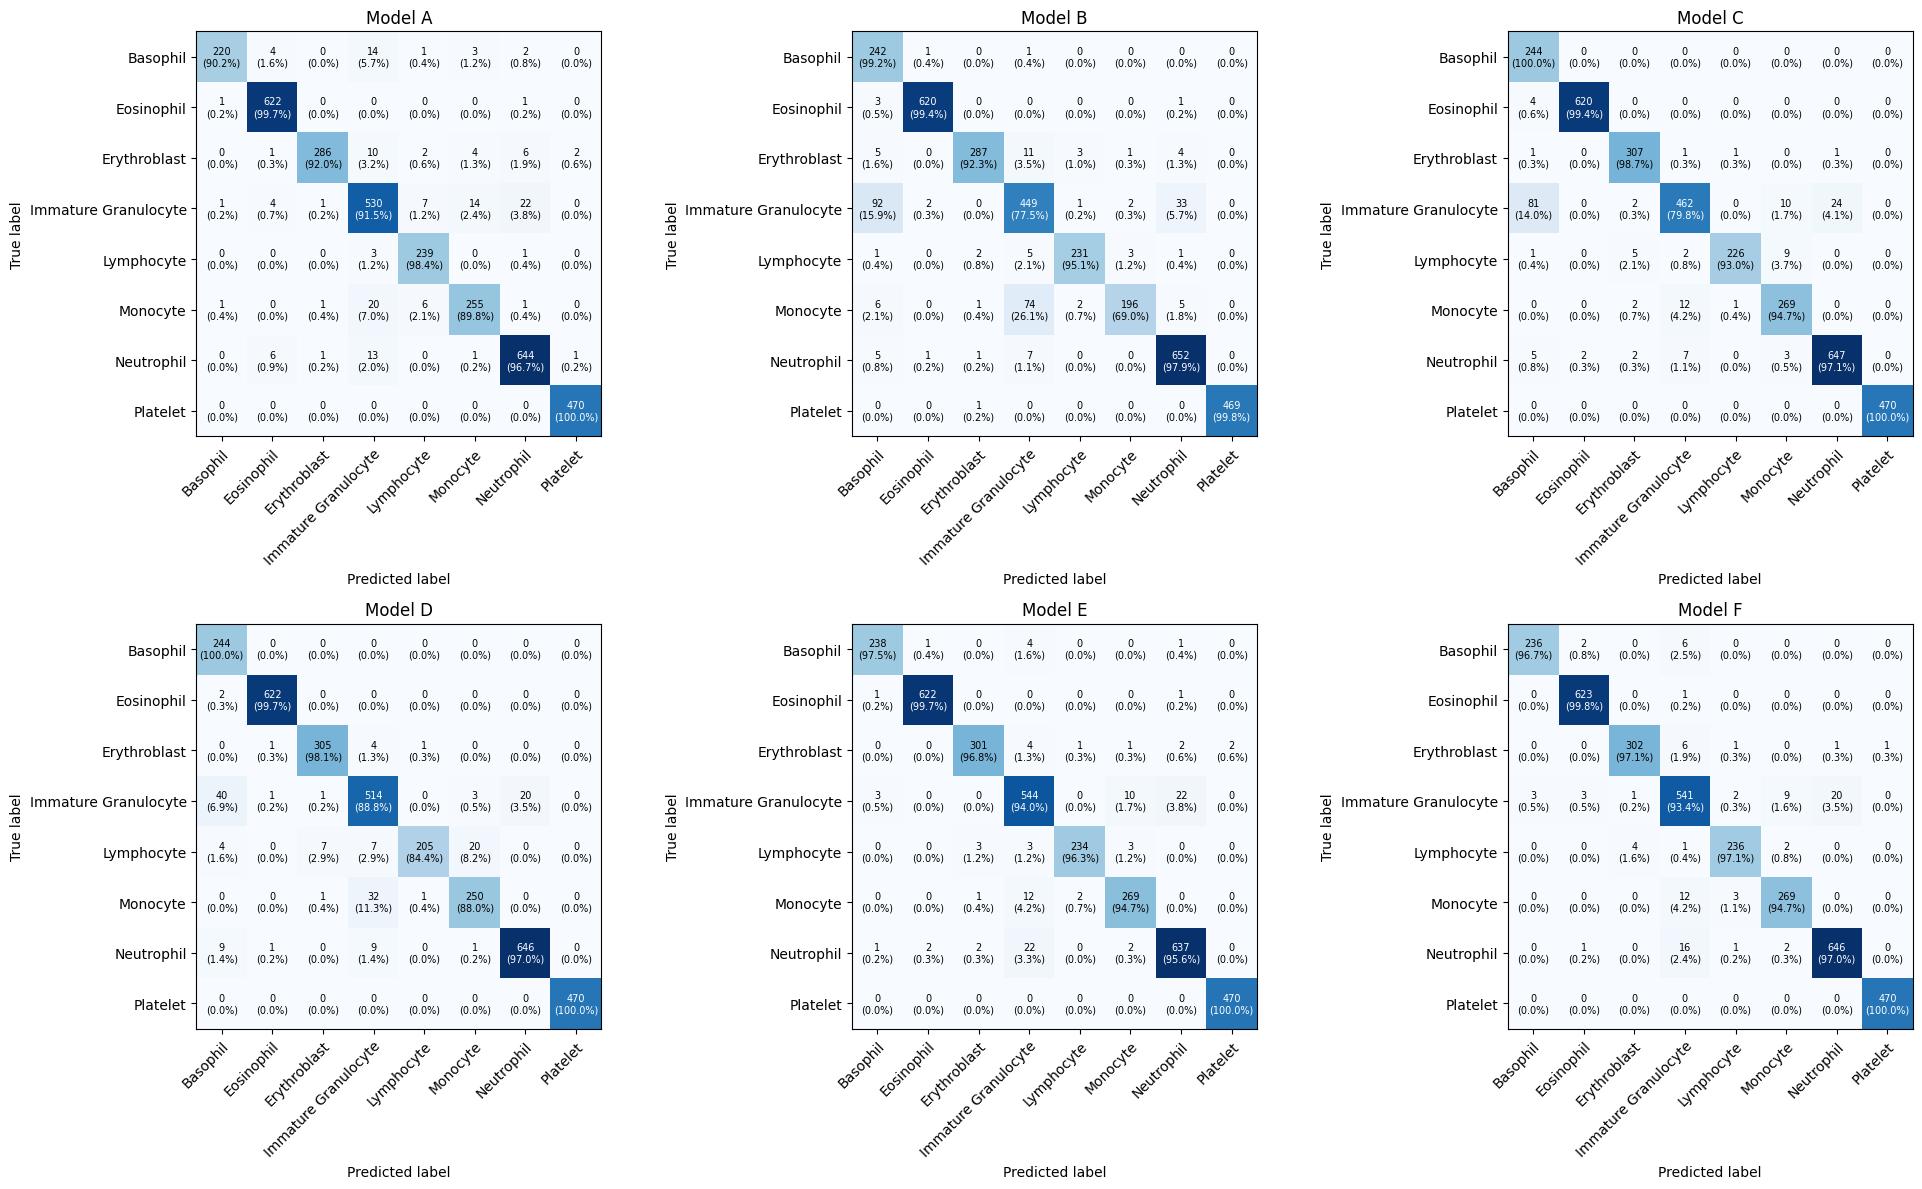

In [10]:
# BloodMNIST class names
CLASS_NAMES = [
    'Basophil',
    'Eosinophil',
    'Erythroblast',
    'Immature Granulocyte',
    'Lymphocyte',
    'Monocyte',
    'Neutrophil',
    'Platelet'
]

def plot_confusion_matrix(y_true, y_pred, class_names, model_name, ax):
    """
    Plot a confusion matrix on a given axis.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=class_names,
        yticklabels=class_names,
        title=model_name,
        ylabel='True label',
        xlabel='Predicted label'
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

    thresh = cm.max() / 2.

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = "white" if cm[i, j] > thresh else "black"
            text_str = f"{cm[i, j]}\n({cm_normalized[i, j]*100:.1f}%)"

            ax.text(
                j, i,
                text_str,
                ha="center",
                va="center",
                color=text_color,
                fontsize=7   # slightly smaller to fit 6 plots
            )

    return im


fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    im = plot_confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        class_names=CLASS_NAMES,
        model_name=f"Model {model_name}",
        ax=ax
    )


plt.tight_layout()
plt.show()